# Why AdaSwarm? 🐝 Two things gradient descent can't do

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/AdaSwarm/AdaSwarm/blob/main/examples/why_adaswarm.ipynb)

`adaswarm.nn.SwarmLoss` runs a particle swarm over candidate model **outputs** and sets the gradient to `output - gbest` instead of the analytic loss slope. Because the swarm only ever *evaluates* the loss (never differentiates it), it can do two things a standard optimiser cannot:

1. **Escape deceptive local minima** in a non-convex output loss.
2. **Train on a non-differentiable loss** (zero gradient everywhere).

We show both, head-to-head with plain Adam, on the same model / data / initialisation.

> ⚠️ Honest scope: this is a **niche** tool. For smooth convex losses (MSE, cross-entropy) plain Adam is as good and much cheaper. AdaSwarm earns its keep only when the loss landscape is nasty — exactly the two cases below.

In [1]:
# %pip install "adaswarm[examples] @ git+https://github.com/AdaSwarm/AdaSwarm.git"  # on Colab
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

import adaswarm.nn

print("adaswarm", adaswarm.__version__, "| torch", torch.__version__)

adaswarm 0.1.0 | torch 2.12.1


In [2]:
def make_model(seed):
    torch.manual_seed(seed)
    return nn.Sequential(nn.Linear(1, 32), nn.Tanh(), nn.Linear(32, 1))

x = torch.linspace(-3, 3, 200).unsqueeze(1)
y = 2.0 * x - 1.0 + 8.0   # target shifted far from the model's initial outputs

def mse(p, t):
    return ((p - t) ** 2).mean()

def train(loss_fn, mode, seed=0, epochs=250, lr=0.05, span=6.0):
    model = make_model(seed)
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = adaswarm.nn.SwarmLoss(loss_fn, seed=seed, span=span) if mode == "adaswarm" else None
    for _ in range(epochs):
        opt.zero_grad()
        out = model(x)
        loss = criterion(out, y) if mode == "adaswarm" else loss_fn(out, y).mean()
        loss.backward()
        opt.step()
    with torch.no_grad():
        return model(x), mse(model(x), y).item()

## Act 1 — Escaping deceptive local minima

The loss between prediction and target has a global minimum at `p == y` but a series of **deceptive local minima** (the cosine term). Gradient descent slides into the nearest trough and stops.

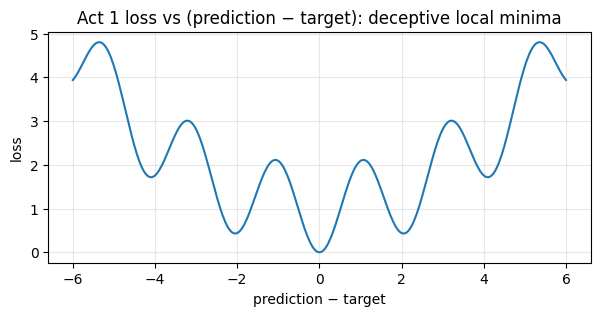

In [3]:
def multiwell(p, t):
    r = p - t
    return 0.1 * r**2 + (1 - torch.cos(3 * r))

# visualise the loss vs prediction error
r = torch.linspace(-6, 6, 400)
plt.figure(figsize=(7, 3))
plt.plot(r, (0.1 * r**2 + (1 - torch.cos(3 * r))))
plt.title("Act 1 loss vs (prediction − target): deceptive local minima")
plt.xlabel("prediction − target"); plt.ylabel("loss"); plt.grid(alpha=0.3); plt.show()

final MSE  —  standard Adam: 3.259   AdaSwarm: 0.020


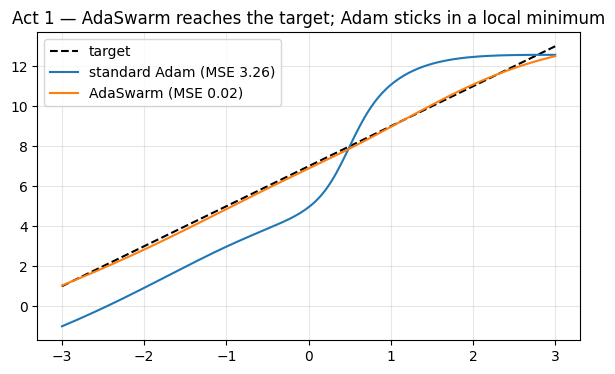

In [4]:
std_fit, std_mse = train(multiwell, "standard")
ada_fit, ada_mse = train(multiwell, "adaswarm")
print(f"final MSE  —  standard Adam: {std_mse:.3f}   AdaSwarm: {ada_mse:.3f}")

plt.figure(figsize=(7, 4))
plt.plot(x, y, 'k--', label='target')
plt.plot(x, std_fit, label=f'standard Adam (MSE {std_mse:.2f})')
plt.plot(x, ada_fit, label=f'AdaSwarm (MSE {ada_mse:.2f})')
plt.title("Act 1 — AdaSwarm reaches the target; Adam sticks in a local minimum")
plt.legend(); plt.grid(alpha=0.3); plt.show()

## Act 2 — A non-differentiable loss (the superpower)

This loss compares **rounded integer levels** — it is piecewise-constant, so its gradient is **zero almost everywhere**. Standard backprop gets no signal and cannot move. AdaSwarm never differentiates the loss, so it trains fine.

final MSE  —  standard Adam: 63.385  (stuck at init)   AdaSwarm: 0.174


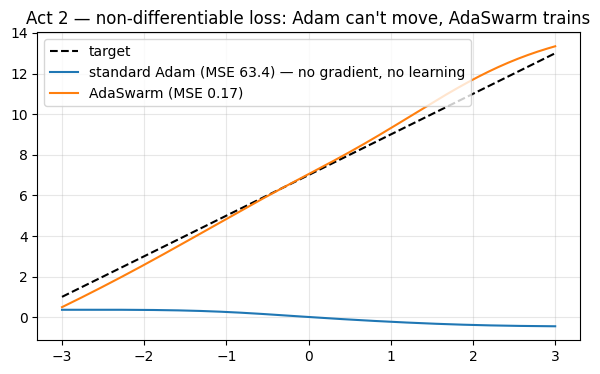

In [5]:
def step_loss(p, t):
    return (p.round() - t.round()).abs()   # non-differentiable, zero grad a.e.

std_fit, std_mse = train(step_loss, "standard", span=8.0)
ada_fit, ada_mse = train(step_loss, "adaswarm", span=8.0)
print(f"final MSE  —  standard Adam: {std_mse:.3f}  (stuck at init)   AdaSwarm: {ada_mse:.3f}")

plt.figure(figsize=(7, 4))
plt.plot(x, y, 'k--', label='target')
plt.plot(x, std_fit, label=f'standard Adam (MSE {std_mse:.1f}) — no gradient, no learning')
plt.plot(x, ada_fit, label=f'AdaSwarm (MSE {ada_mse:.2f})')
plt.title("Act 2 — non-differentiable loss: Adam can't move, AdaSwarm trains")
plt.legend(); plt.grid(alpha=0.3); plt.show()

## Where this matters in the real world

The two properties above map onto real problem classes:

- **Periodic / wrapped outputs** (multi-modal like Act 1): phase retrieval, phase unwrapping/InSAR, audio pitch (octave errors), direction-of-arrival, rotation/pose (SO(3)).
- **Non-differentiable / black-box losses** (like Act 2): optimising discrete metrics directly (F1, AUC, IoU, word-error-rate), simulator-in-the-loop training, quantised/discrete-output fitting.
- **Multi-modal scientific fitting**: spectral peak fitting (NMR, mass-spec), stiff PDE residuals in PINNs.

**Rule of thumb:** reach for `SwarmLoss` when your *output* loss is non-convex or non-differentiable and plain training stalls. For smooth convex losses, stick with a standard optimiser — it's cheaper and just as good.

```python
import adaswarm.nn
criterion = adaswarm.nn.SwarmLoss(my_elementwise_loss)   # loss_fn(p, y) -> per-element tensor
loss = criterion(model(x), y)
loss.backward()   # standard optimiser step from here
```